In [14]:
import numpy as np 
import uproot
import matplotlib.pyplot as plt



In [2]:
file = uproot.open("/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/2x2_CC_pi0/caf_analysis/data_quality/outputs/Physics_DQM_Run1_FullRun1NominalHVv11/Physics_DQM_Run1_FullRun1NominalHVv11.root")

pot_tree = file["beam/t_beam_SpillPOTAndStartTime"]

In [9]:
pot_array = pot_tree.arrays(library="pd")

pot = pot_array["pot"].to_numpy()*1e13
start_time_sec = pot_array["start_time_sec"].to_numpy()
start_time_nsec = pot_array["start_time_nsec"].to_numpy()
mx2_start_time_sec = pot_array["mx2_start_time_sec"].to_numpy()
mx2_start_time_nsec = pot_array["mx2_start_time_nsec"].to_numpy()

lar2x2_start_time = start_time_sec + start_time_nsec * 1e-9
mx2_start_time = mx2_start_time_sec + mx2_start_time_nsec * 1e-9

lar2x2_start_time_zero_mask = lar2x2_start_time == 0
mx2_start_time_zero_mask = mx2_start_time == 0
pot_zero_mask = pot == 0
print(f"Total number of entries: {len(pot)}")
print(f"Number of entries with lar2x2_start_time == 0: {np.sum(lar2x2_start_time_zero_mask)}")
print(f"Number of entries with mx2_start_time == 0: {np.sum(mx2_start_time_zero_mask)}")
print(f"Number of entries with pot == 0: {np.sum(pot_zero_mask)}")
print(f"Number of entries with both lar2x2_start_time and mx2_start_time == 0: {np.sum(lar2x2_start_time_zero_mask & mx2_start_time_zero_mask)}")
print(f"Number of entries with both lar2x2_start_time and pot == 0: {np.sum(lar2x2_start_time_zero_mask & pot_zero_mask)}")
print(f"Number of entries with both mx2_start_time and pot == 0: {np.sum(mx2_start_time_zero_mask & pot_zero_mask)}")
print(f"Number of entries with lar2x2_start_time == 0, mx2_start_time == 0, and pot == 0: {np.sum(lar2x2_start_time_zero_mask & mx2_start_time_zero_mask & pot_zero_mask)}")

Total number of entries: 3595024
Number of entries with lar2x2_start_time == 0: 4128
Number of entries with mx2_start_time == 0: 3420235
Number of entries with pot == 0: 3417865
Number of entries with both lar2x2_start_time and mx2_start_time == 0: 38
Number of entries with both lar2x2_start_time and pot == 0: 48
Number of entries with both mx2_start_time and pot == 0: 3417438
Number of entries with lar2x2_start_time == 0, mx2_start_time == 0, and pot == 0: 38


2x2 Timestamp diffs: [ 5.79209328e-02  1.90000534e-02  5.00600338e-02 ...  5.60400486e-02
  1.16250515e-02 -1.72077484e+09]
MX2 Timestamp diffs: [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
 0.00000000e+00 1.72077484e+09]


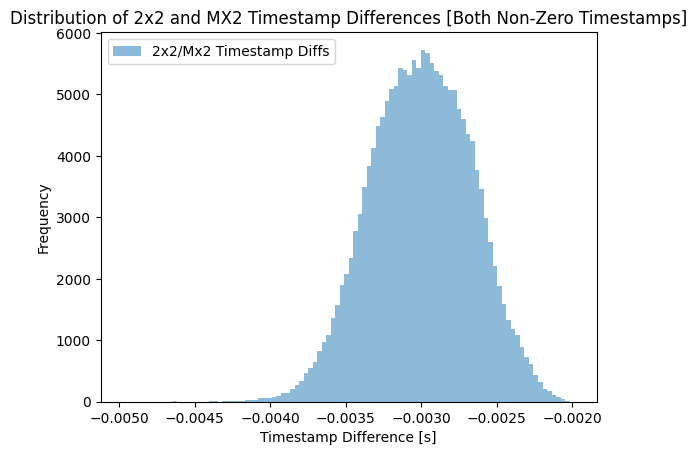

In [31]:
no_timestamp_mask = lar2x2_start_time_zero_mask & mx2_start_time_zero_mask


# Remove events with no timestamps from the arrays
pot_with_timestamp = pot[~no_timestamp_mask]
lar2x2_start_time_with_timestamp = lar2x2_start_time[~no_timestamp_mask]
mx2_start_time_with_timestamp = mx2_start_time[~no_timestamp_mask]

print("2x2 Timestamp diffs:", np.diff(lar2x2_start_time_with_timestamp))
print("MX2 Timestamp diffs:", np.diff(mx2_start_time_with_timestamp))


lar2x2_zero_mask = lar2x2_start_time_with_timestamp == 0
mx2_zero_mask = mx2_start_time_with_timestamp == 0
lar2x2_or_mx2_zero_mask = lar2x2_zero_mask | mx2_zero_mask
diff_2x2_Mx2 = lar2x2_start_time_with_timestamp[~lar2x2_or_mx2_zero_mask] - mx2_start_time_with_timestamp[~lar2x2_or_mx2_zero_mask]


plt.hist(diff_2x2_Mx2, bins=100, alpha=0.5, label='2x2/Mx2 Timestamp Diffs')
#plt.hist(np.diff(mx2_start_time_with_timestamp[mx2_start_time_with_timestamp != 0]), bins=100, range=(0, 10), color='orange', alpha=0.5, label='MX2 Timestamp Diffs')
plt.xlabel('Timestamp Difference [s]')
#plt.xscale('log')
#plt.yscale('log')
plt.ylabel('Frequency')
#plt.xlim(1e-9, 10)
plt.title('Distribution of 2x2 and MX2 Timestamp Differences [Both Non-Zero Timestamps]')
plt.legend()
plt.show()

Number of remaining zero timestamps after filtering: 0
Number of remaining zero POT after filtering: 3417827


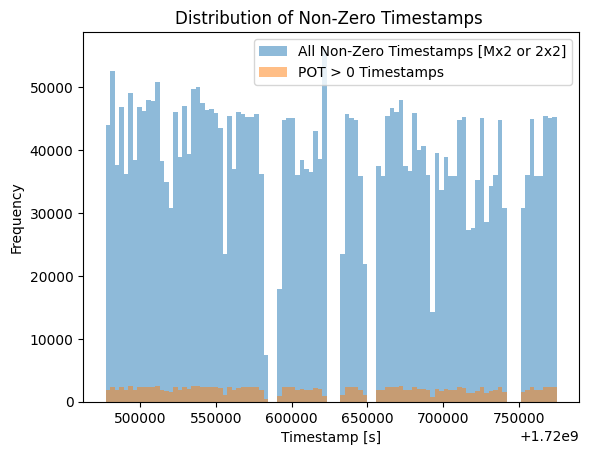

Number of unique timestamps after filtering: 177159
Number of timestamps: 177159


In [ ]:
all_nonzero_timestamps = np.where(~lar2x2_zero_mask, lar2x2_start_time_with_timestamp, mx2_start_time_with_timestamp)
all_nonzero_timestamps_check_mask = all_nonzero_timestamps == 0
print("Number of remaining zero timestamps after filtering:", np.sum(all_nonzero_timestamps_check_mask))
pot_zero_mask = pot_with_timestamp == 0
print("Number of remaining zero POT after filtering:", np.sum(pot_zero_mask))

pot_zero_mask = pot_with_timestamp == 0

pot_lar2x2_timestamps = pot_with_timestamp[~lar2x2_zero_mask & ~pot_zero_mask]
lar2x2_nonzero_timestamps = lar2x2_start_time_with_timestamp[~lar2x2_zero_mask & ~pot_zero_mask]

pot_mx2_timestamps = pot_with_timestamp[lar2x2_zero_mask & ~pot_zero_mask]
mx2_nonzero_timestamps = mx2_start_time_with_timestamp[lar2x2_zero_mask & ~pot_zero_mask]

plt.hist(all_nonzero_timestamps[~all_nonzero_timestamps_check_mask], bins=100, alpha=0.5, label='All Non-Zero Timestamps [Mx2 or 2x2]')
plt.hist(all_nonzero_timestamps[~pot_zero_mask], bins=100, alpha=0.5, label='POT > 0 Timestamps')
plt.xlabel('Timestamp [s]')
plt.ylabel('Frequency')
plt.title('Distribution of Non-Zero Timestamps ')
plt.legend()
plt.show()
print("Number of unique timestamps after filtering:", len(np.unique(all_nonzero_timestamps[~pot_zero_mask])))
print("Number of timestamps:", len(all_nonzero_timestamps[~pot_zero_mask]))

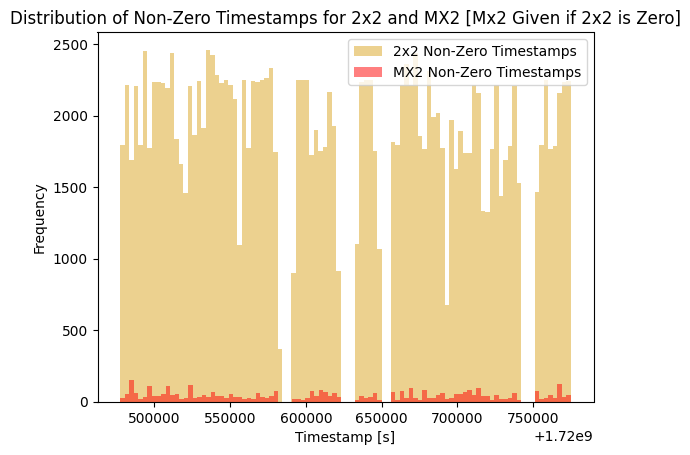

In [40]:
pot_zero_mask = pot_with_timestamp == 0

pot_lar2x2_timestamps = pot_with_timestamp[~lar2x2_zero_mask & ~pot_zero_mask]
lar2x2_nonzero_timestamps = lar2x2_start_time_with_timestamp[~lar2x2_zero_mask & ~pot_zero_mask]

pot_mx2_timestamps = pot_with_timestamp[lar2x2_zero_mask & ~pot_zero_mask]
mx2_nonzero_timestamps = mx2_start_time_with_timestamp[lar2x2_zero_mask & ~pot_zero_mask]

plt.hist(lar2x2_nonzero_timestamps, bins=100, alpha=0.5, color='goldenrod', label='2x2 Non-Zero Timestamps')
plt.hist(mx2_nonzero_timestamps, bins=100, alpha=0.5, color='red', label='MX2 Non-Zero Timestamps')
plt.xlabel('Timestamp [s]')
plt.ylabel('Frequency')
plt.title('Distribution of Non-Zero Timestamps for 2x2 and MX2 [Mx2 Given if 2x2 is Zero]')
plt.legend()
plt.show()

177159
Mean POT for 2x2 Non-Zero Timestamps: 47928207251728.06
Mean POT for MX2 Non-Zero Timestamps: 48390614979619.555
Median POT for 2x2 Non-Zero Timestamps: 50186441195520.01
Median POT for MX2 Non-Zero Timestamps: 50260407746560.0
Overall Mean POT for Non-Zero Timestamps: 47938856575385.33
Overall Median POT for Non-Zero Timestamps: 50186441195520.01
Total POT for 2x2 Non-Zero Timestamps within ±5% of Overall Median POT/Spill: 8.147847433427091e+18
Total POT for MX2 Non-Zero Timestamps within ±5% of Overall Median POT/Spill: 1.945607923082199e+17


Text(0.99, 0.9, 'Total POT from Spills with POT within ±5% of Overall Median POT/Spill: 8.34e+18 (98.23%)')

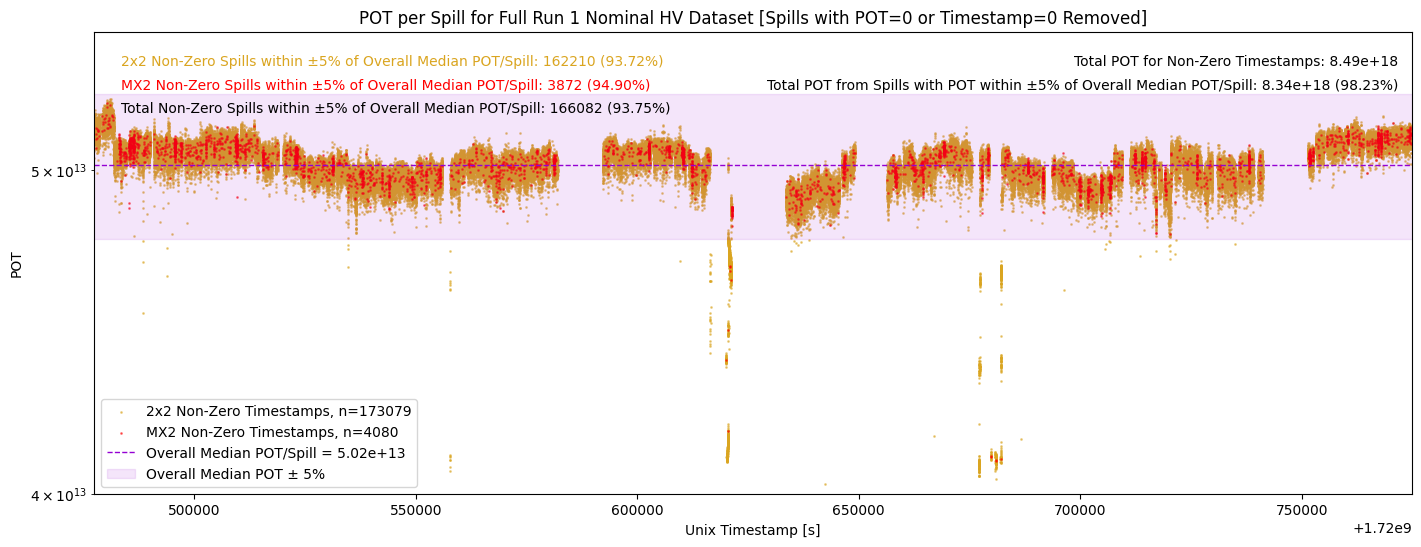

In [67]:
min_2x2_ts = np.min(lar2x2_nonzero_timestamps)
max_2x2_ts = np.max(lar2x2_nonzero_timestamps)
min_mx2_ts = np.min(mx2_nonzero_timestamps)
max_mx2_ts = np.max(mx2_nonzero_timestamps)

fig, ax = plt.subplots(figsize=(17, 6))
print(len(lar2x2_nonzero_timestamps)+ len(mx2_nonzero_timestamps))
ax.scatter(lar2x2_nonzero_timestamps, pot_lar2x2_timestamps, alpha=0.5, color='goldenrod', s=1, label=f'2x2 Non-Zero Timestamps, n={len(lar2x2_nonzero_timestamps)}')
ax.scatter(mx2_nonzero_timestamps, pot_mx2_timestamps, alpha=0.5, color='red', s=1, label=f'MX2 Non-Zero Timestamps, n={len(mx2_nonzero_timestamps)}')

ax.set_xlim(xmin=np.min([min_2x2_ts, min_mx2_ts]), xmax=np.max([max_2x2_ts, max_mx2_ts]))
ax.set_ylabel("POT")
ax.set_xlabel("Unix Timestamp [s]")
ax.set_title("POT per Spill for Full Run 1 Nominal HV Dataset [Spills with POT=0 or Timestamp=0 Removed]")
ax.set_yscale('log')
ax.set_ylim(4.*1e13, 5.5*1e13)

mean_lar2x2_nonzero_pot = np.mean(pot_lar2x2_timestamps)
mean_mx2_nonzero_pot = np.mean(pot_mx2_timestamps)
median_lar2x2_nonzero_pot = np.median(pot_lar2x2_timestamps)
median_mx2_nonzero_pot = np.median(pot_mx2_timestamps)
overall_mean_pot = np.mean(np.concatenate((pot_lar2x2_timestamps, pot_mx2_timestamps)))
overall_median_pot = np.median(np.concatenate((pot_lar2x2_timestamps, pot_mx2_timestamps)))
print("Mean POT for 2x2 Non-Zero Timestamps:", mean_lar2x2_nonzero_pot)
print("Mean POT for MX2 Non-Zero Timestamps:", mean_mx2_nonzero_pot)
print("Median POT for 2x2 Non-Zero Timestamps:", median_lar2x2_nonzero_pot)
print("Median POT for MX2 Non-Zero Timestamps:", median_mx2_nonzero_pot)
print("Overall Mean POT for Non-Zero Timestamps:", overall_mean_pot)    
print("Overall Median POT for Non-Zero Timestamps:", overall_median_pot)
#ax.hlines(overall_mean_pot, xmin=np.min([min_2x2_ts, min_mx2_ts]), xmax=np.max([max_2x2_ts, max_mx2_ts]), color='blue', linestyle='dashed', linewidth=1, label='Overall Mean')
ax.hlines(overall_median_pot, xmin=np.min([min_2x2_ts, min_mx2_ts]), xmax=np.max([max_2x2_ts, max_mx2_ts]), color='darkviolet', linestyle='dashed', linewidth=1, label=f'Overall Median POT/Spill = {overall_median_pot:.2e}')
lar2x2_nonzero_between_median_pm5percent_mask = (pot_lar2x2_timestamps >= overall_median_pot*0.95) & (pot_lar2x2_timestamps <= overall_median_pot*1.05)
mx2_nonzero_between_median_pm5percent_mask = (pot_mx2_timestamps >= overall_median_pot*0.95) & (pot_mx2_timestamps <= overall_median_pot*1.05)
number_lar2x2_nonzero_between_median_pm5percent = np.sum(lar2x2_nonzero_between_median_pm5percent_mask)
number_mx2_nonzero_between_median_pm5percent = np.sum(mx2_nonzero_between_median_pm5percent_mask)
total_nonzero_between_median_pm5percent = number_lar2x2_nonzero_between_median_pm5percent + number_mx2_nonzero_between_median_pm5percent
total_nonzero_spills = len(pot_lar2x2_timestamps) + len(pot_mx2_timestamps)
ax.text(0.02, 0.95, f'2x2 Non-Zero Spills within ±5% of Overall Median POT/Spill: {number_lar2x2_nonzero_between_median_pm5percent} ({number_lar2x2_nonzero_between_median_pm5percent/len(pot_lar2x2_timestamps)*100:.2f}%)', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='goldenrod')
ax.text(0.02, 0.90, f'MX2 Non-Zero Spills within ±5% of Overall Median POT/Spill: {number_mx2_nonzero_between_median_pm5percent} ({number_mx2_nonzero_between_median_pm5percent/len(pot_mx2_timestamps)*100:.2f}%)', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='red')
ax.text(0.02, 0.85, f'Total Non-Zero Spills within ±5% of Overall Median POT/Spill: {total_nonzero_between_median_pm5percent} ({total_nonzero_between_median_pm5percent/total_nonzero_spills*100:.2f}%)', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='black')
#mean_five_percent = overall_mean_pot*0.05
#mean_upper = overall_mean_pot + mean_five_percent
#mean_lower = overall_mean_pot - mean_five_percent
#ax.fill_between([0, 1.73*1e9], mean_lower, mean_upper, color='blue', alpha=0.1, label='Mean ± 5%')
median_five_percent = overall_median_pot*0.05
median_upper = overall_median_pot + median_five_percent
median_lower = overall_median_pot - median_five_percent 
ax.fill_between([0, 1.73*1e9], median_lower, median_upper, color='darkviolet', alpha=0.1, label='Overall Median POT ± 5%')
ax.legend()

total_pot = np.sum(pot_lar2x2_timestamps) + np.sum(pot_mx2_timestamps)
pot_lar2x2_between_median_pm5percent = pot_lar2x2_timestamps[lar2x2_nonzero_between_median_pm5percent_mask]
print("Total POT for 2x2 Non-Zero Timestamps within ±5% of Overall Median POT/Spill:", np.sum(pot_lar2x2_between_median_pm5percent))
pot_mx2_between_median_pm5percent = pot_mx2_timestamps[mx2_nonzero_between_median_pm5percent_mask]
print("Total POT for MX2 Non-Zero Timestamps within ±5% of Overall Median POT/Spill:", np.sum(pot_mx2_between_median_pm5percent))
total_pot_between_median_pm5percent = np.sum(pot_lar2x2_between_median_pm5percent) + np.sum(pot_mx2_between_median_pm5percent)
ax.text(0.99, 0.95, f'Total POT for Non-Zero Timestamps: {total_pot:.2e}', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='black', horizontalalignment='right')
ax.text(0.99, 0.90, f'Total POT from Spills with POT within ±5% of Overall Median POT/Spill: {total_pot_between_median_pm5percent:.2e} ({total_pot_between_median_pm5percent/total_pot*100:.2f}%)', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='black', horizontalalignment='right')

177159
Mean POT for 2x2 Non-Zero Timestamps: 47928207251728.06
Mean POT for MX2 Non-Zero Timestamps: 48390614979619.555
Median POT for 2x2 Non-Zero Timestamps: 50186441195520.01
Median POT for MX2 Non-Zero Timestamps: 50260407746560.0
Overall Mean POT for Non-Zero Timestamps: 47938856575385.33
Overall Median POT for Non-Zero Timestamps: 50186441195520.01


'total_pot = np.sum(pot_lar2x2_timestamps) + np.sum(pot_mx2_timestamps)\npot_lar2x2_between_median_pm5percent = pot_lar2x2_timestamps[lar2x2_nonzero_between_median_pm5percent_mask]\nprint("Total POT for 2x2 Non-Zero Timestamps within ±5% of Overall Median POT/Spill:", np.sum(pot_lar2x2_between_median_pm5percent))\npot_mx2_between_median_pm5percent = pot_mx2_timestamps[mx2_nonzero_between_median_pm5percent_mask]\nprint("Total POT for MX2 Non-Zero Timestamps within ±5% of Overall Median POT/Spill:", np.sum(pot_mx2_between_median_pm5percent))\ntotal_pot_between_median_pm5percent = np.sum(pot_lar2x2_between_median_pm5percent) + np.sum(pot_mx2_between_median_pm5percent)\nax.text(0.99, 0.95, f\'Total POT for Non-Zero Timestamps: {total_pot:.2e}\', transform=ax.transAxes, fontsize=10, verticalalignment=\'top\', color=\'black\', horizontalalignment=\'right\')\nax.text(0.99, 0.90, f\'Total POT from Spills with POT within ±5% of Overall Median POT/Spill: {total_pot_between_median_pm5percent:.2e}

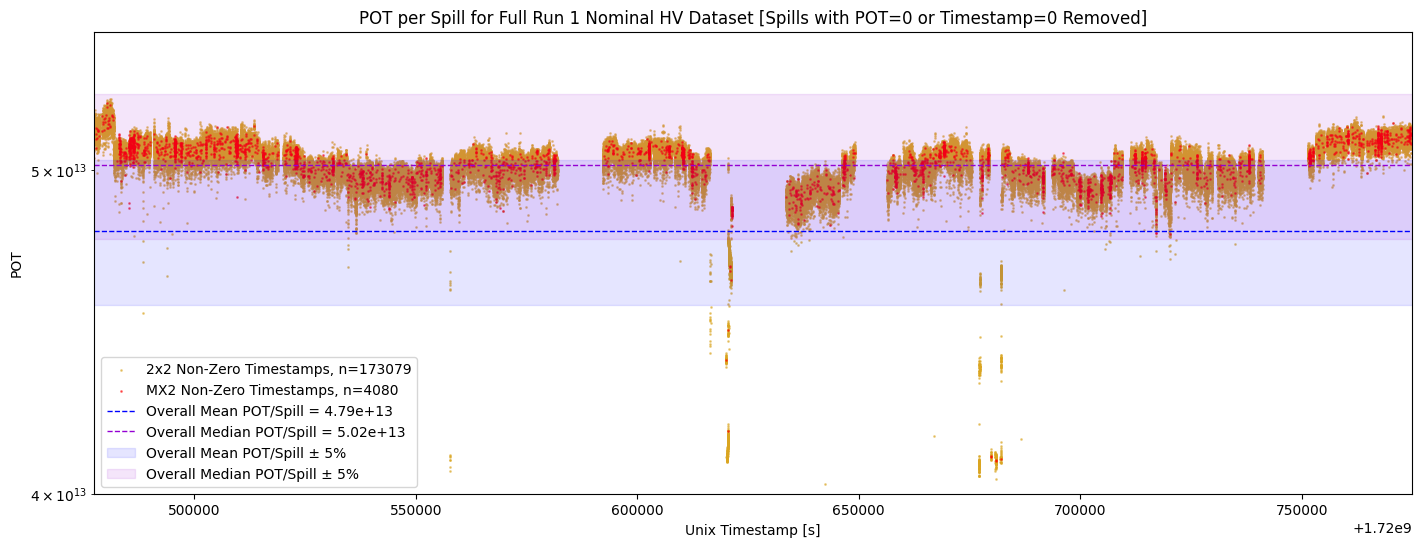

In [72]:
min_2x2_ts = np.min(lar2x2_nonzero_timestamps)
max_2x2_ts = np.max(lar2x2_nonzero_timestamps)
min_mx2_ts = np.min(mx2_nonzero_timestamps)
max_mx2_ts = np.max(mx2_nonzero_timestamps)

fig, ax = plt.subplots(figsize=(17, 6))
print(len(lar2x2_nonzero_timestamps)+ len(mx2_nonzero_timestamps))
ax.scatter(lar2x2_nonzero_timestamps, pot_lar2x2_timestamps, alpha=0.5, color='goldenrod', s=1, label=f'2x2 Non-Zero Timestamps, n={len(lar2x2_nonzero_timestamps)}')
ax.scatter(mx2_nonzero_timestamps, pot_mx2_timestamps, alpha=0.5, color='red', s=1, label=f'MX2 Non-Zero Timestamps, n={len(mx2_nonzero_timestamps)}')

ax.set_xlim(xmin=np.min([min_2x2_ts, min_mx2_ts]), xmax=np.max([max_2x2_ts, max_mx2_ts]))
ax.set_ylabel("POT")
ax.set_xlabel("Unix Timestamp [s]")
ax.set_title("POT per Spill for Full Run 1 Nominal HV Dataset [Spills with POT=0 or Timestamp=0 Removed]")
ax.set_yscale('log')
ax.set_ylim(4.*1e13, 5.5*1e13)

mean_lar2x2_nonzero_pot = np.mean(pot_lar2x2_timestamps)
mean_mx2_nonzero_pot = np.mean(pot_mx2_timestamps)
median_lar2x2_nonzero_pot = np.median(pot_lar2x2_timestamps)
median_mx2_nonzero_pot = np.median(pot_mx2_timestamps)
overall_mean_pot = np.mean(np.concatenate((pot_lar2x2_timestamps, pot_mx2_timestamps)))
overall_median_pot = np.median(np.concatenate((pot_lar2x2_timestamps, pot_mx2_timestamps)))
print("Mean POT for 2x2 Non-Zero Timestamps:", mean_lar2x2_nonzero_pot)
print("Mean POT for MX2 Non-Zero Timestamps:", mean_mx2_nonzero_pot)
print("Median POT for 2x2 Non-Zero Timestamps:", median_lar2x2_nonzero_pot)
print("Median POT for MX2 Non-Zero Timestamps:", median_mx2_nonzero_pot)
print("Overall Mean POT for Non-Zero Timestamps:", overall_mean_pot)    
print("Overall Median POT for Non-Zero Timestamps:", overall_median_pot)
ax.hlines(overall_mean_pot, xmin=np.min([min_2x2_ts, min_mx2_ts]), xmax=np.max([max_2x2_ts, max_mx2_ts]), color='blue', linestyle='dashed', linewidth=1, label=f'Overall Mean POT/Spill = {overall_mean_pot:.2e}')
ax.hlines(overall_median_pot, xmin=np.min([min_2x2_ts, min_mx2_ts]), xmax=np.max([max_2x2_ts, max_mx2_ts]), color='darkviolet', linestyle='dashed', linewidth=1, label=f'Overall Median POT/Spill = {overall_median_pot:.2e}')
lar2x2_nonzero_between_median_pm5percent_mask = (pot_lar2x2_timestamps >= overall_median_pot*0.95) & (pot_lar2x2_timestamps <= overall_median_pot*1.05)
mx2_nonzero_between_median_pm5percent_mask = (pot_mx2_timestamps >= overall_median_pot*0.95) & (pot_mx2_timestamps <= overall_median_pot*1.05)
number_lar2x2_nonzero_between_median_pm5percent = np.sum(lar2x2_nonzero_between_median_pm5percent_mask)
number_mx2_nonzero_between_median_pm5percent = np.sum(mx2_nonzero_between_median_pm5percent_mask)
total_nonzero_between_median_pm5percent = number_lar2x2_nonzero_between_median_pm5percent + number_mx2_nonzero_between_median_pm5percent
total_nonzero_spills = len(pot_lar2x2_timestamps) + len(pot_mx2_timestamps)
#ax.text(0.02, 0.95, f'2x2 Non-Zero Spills within ±5% of Overall Median POT/Spill: {number_lar2x2_nonzero_between_median_pm5percent} ({number_lar2x2_nonzero_between_median_pm5percent/len(pot_lar2x2_timestamps)*100:.2f}%)', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='goldenrod')
#ax.text(0.02, 0.90, f'MX2 Non-Zero Spills within ±5% of Overall Median POT/Spill: {number_mx2_nonzero_between_median_pm5percent} ({number_mx2_nonzero_between_median_pm5percent/len(pot_mx2_timestamps)*100:.2f}%)', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='red')
#ax.text(0.02, 0.85, f'Total Non-Zero Spills within ±5% of Overall Median POT/Spill: {total_nonzero_between_median_pm5percent} ({total_nonzero_between_median_pm5percent/total_nonzero_spills*100:.2f}%)', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='black')
mean_five_percent = overall_mean_pot*0.05
mean_upper = overall_mean_pot + mean_five_percent
mean_lower = overall_mean_pot - mean_five_percent
ax.fill_between([0, 1.73*1e9], mean_lower, mean_upper, color='blue', alpha=0.1, label='Overall Mean POT/Spill ± 5%')
median_five_percent = overall_median_pot*0.05
median_upper = overall_median_pot + median_five_percent
median_lower = overall_median_pot - median_five_percent 
ax.fill_between([0, 1.73*1e9], median_lower, median_upper, color='darkviolet', alpha=0.1, label='Overall Median POT/Spill ± 5%')
ax.legend()

'''total_pot = np.sum(pot_lar2x2_timestamps) + np.sum(pot_mx2_timestamps)
pot_lar2x2_between_median_pm5percent = pot_lar2x2_timestamps[lar2x2_nonzero_between_median_pm5percent_mask]
print("Total POT for 2x2 Non-Zero Timestamps within ±5% of Overall Median POT/Spill:", np.sum(pot_lar2x2_between_median_pm5percent))
pot_mx2_between_median_pm5percent = pot_mx2_timestamps[mx2_nonzero_between_median_pm5percent_mask]
print("Total POT for MX2 Non-Zero Timestamps within ±5% of Overall Median POT/Spill:", np.sum(pot_mx2_between_median_pm5percent))
total_pot_between_median_pm5percent = np.sum(pot_lar2x2_between_median_pm5percent) + np.sum(pot_mx2_between_median_pm5percent)
ax.text(0.99, 0.95, f'Total POT for Non-Zero Timestamps: {total_pot:.2e}', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='black', horizontalalignment='right')
ax.text(0.99, 0.90, f'Total POT from Spills with POT within ±5% of Overall Median POT/Spill: {total_pot_between_median_pm5percent:.2e} ({total_pot_between_median_pm5percent/total_pot*100:.2f}%)', transform=ax.transAxes, fontsize=10, verticalalignment='top', color='black', horizontalalignment='right')'''

In [ ]:
fig, ax = plt.subplots(figsize=(17, 6))
print(len(lar2x2_nonzero_timestamps)+ len(mx2_nonzero_timestamps))
ax.scatter(lar2x2_nonzero_timestamps, pot_lar2x2_timestamps, alpha=0.5, color='goldenrod', s=1, label=f'2x2 Non-Zero Timestamps, n={len(lar2x2_nonzero_timestamps)}')
ax.scatter(mx2_nonzero_timestamps, pot_mx2_timestamps, alpha=0.5, color='red', s=1, label=f'MX2 Non-Zero Timestamps, n={len(mx2_nonzero_timestamps)}')

ax.set_xlim(xmin=np.min([min_2x2_ts, min_mx2_ts]), xmax=np.max([max_2x2_ts, max_mx2_ts]))
ax.set_ylabel("POT")
ax.set_xlabel("Unix Timestamp [s]")
ax.set_title("POT per Spill for Full Run 1 Nominal HV Dataset [Spills with POT=0 or Timestamp=0 Removed]")
ax.set_yscale('log')
plt.legend()

In [12]:
lar2x2_non_zero_only = 0
mx2_non_zero_only = 0
lar2x2_and_mx2_non_zero = 0
lar2x2_mx2_nonzero_mismatch = 0

for i in range(len(pot_with_timestamp)):
    lar2x2_start = lar2x2_start_time_with_timestamp[i]
    mx2_start = mx2_start_time_with_timestamp[i]
    if lar2x2_start != 0 and mx2_start != 0:
        if abs(lar2x2_start - mx2_start) > 0.01:
            print(f"Entry {i}: lar2x2_start_time = {lar2x2_start}, mx2_start_time = {mx2_start}")
            lar2x2_mx2_nonzero_mismatch += 1
        lar2x2_and_mx2_non_zero += 1
    elif lar2x2_start == 0 and mx2_start != 0:
        #print(f"Entry {i}: lar2x2_start_time == 0, mx2_start_time = {mx2_start}")
        mx2_non_zero_only += 1
    elif lar2x2_start != 0 and mx2_start == 0:
        #print(f"Entry {i}: lar2x2_start_time = {lar2x2_start}, mx2_start_time == 0")
        lar2x2_non_zero_only += 1

print(f"Number of entries with both lar2x2_start_time and mx2_start_time non-zero: {lar2x2_and_mx2_non_zero}")
print(f"Number of entries with lar2x2_start_time non-zero and mx2_start_time zero: {lar2x2_non_zero_only}")
print(f"Number of entries with lar2x2_start_time zero and mx2_start_time non-zero: {mx2_non_zero_only}")
print(f"Number of entries with both lar2x2_start_time and mx2_start_time non-zero but mismatched: {lar2x2_mx2_nonzero_mismatch}")

Number of entries with both lar2x2_start_time and mx2_start_time non-zero: 170699
Number of entries with lar2x2_start_time non-zero and mx2_start_time zero: 3420197
Number of entries with lar2x2_start_time zero and mx2_start_time non-zero: 4090
Number of entries with both lar2x2_start_time and mx2_start_time non-zero but mismatched: 0


In [ ]:
no_lar_timestamp_mask = lar2x2_start_time_zero_mask & ~mx2_start_time_zero_mask
pot_no

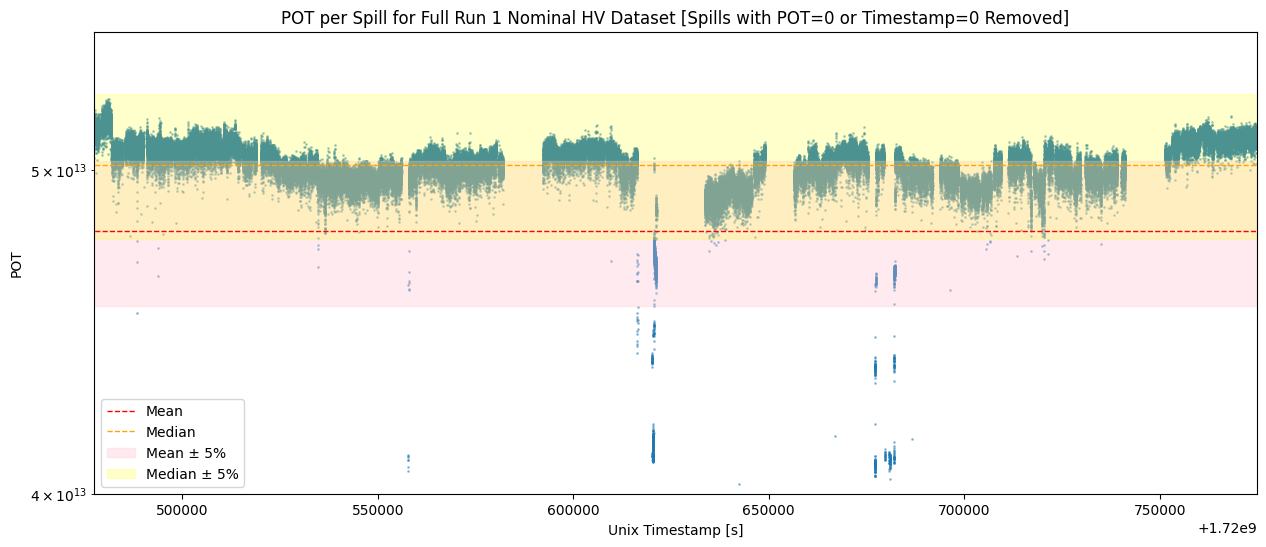

In [56]:
pot_array_with_start_time_sec_zero = pot_array[start_time_sec_zero_mask]
pot_array_with_non_zero_start_time_sec = pot_array[~start_time_sec_zero_mask]

import matplotlib.pyplot as plt
pot = pot_array_with_non_zero_start_time_sec["pot"].to_numpy()*1e13
start_time_sec = pot_array_with_non_zero_start_time_sec["start_time_sec"].to_numpy()
start_time_nsec = pot_array_with_non_zero_start_time_sec["start_time_nsec"].to_numpy()
start_time = start_time_sec + start_time_nsec*1e-9

non_zero_pot_mask = pot != 0
pot = pot[non_zero_pot_mask]
start_time = start_time[non_zero_pot_mask]

fig, ax = plt.subplots(figsize=(15, 6))
plt.scatter(start_time, pot, s=1, alpha=0.4)
plt.yscale('log')
plt.ylim(4.*1e13, 5.5*1e13)
plt.hlines(np.mean(pot), xmin=0, xmax=1.73*1e9, color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.hlines(np.median(pot), xmin=0, xmax=1.73*1e9, color='orange', linestyle='dashed', linewidth=1, label='Median')
mean_five_percent = np.mean(pot)*0.05
mean_upper = np.mean(pot) + mean_five_percent
mean_lower = np.mean(pot) - mean_five_percent
plt.fill_between([0, 1.73*1e9], mean_lower, mean_upper, color='pink', alpha=0.3, label='Mean ± 5%')
median_five_percent = np.median(pot)*0.05
median_upper = np.median(pot) + median_five_percent
median_lower = np.median(pot) - median_five_percent 
plt.fill_between([0, 1.73*1e9], median_lower, median_upper, color='yellow', alpha=0.2, label='Median ± 5%')


plt.xlim(xmin=np.min(start_time), xmax=np.max(start_time))
plt.ylabel("POT")
plt.xlabel("Unix Timestamp [s]")
plt.title("POT per Spill for Full Run 1 Nominal HV Dataset [Spills with POT=0 or Timestamp=0 Removed]")
plt.legend()


In [53]:
non_zero_pot_mask = pot != 0
print(f"Number of entries with non-zero POT: {np.sum(non_zero_pot_mask)}")

Number of entries with non-zero POT: 173079


Mean POT:  47928207251728.06
Median POT:  50186441195520.01


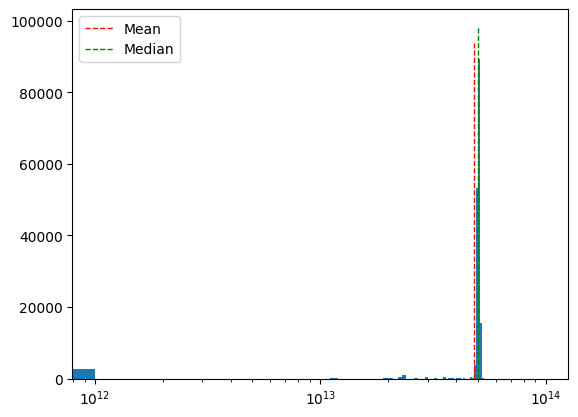

In [54]:
plt.hist(pot[non_zero_pot_mask], bins=100, range=(0, 1e14))
print("Mean POT: ", np.mean(pot[non_zero_pot_mask]))
print("Median POT: ", np.median(pot[non_zero_pot_mask]))
plt.vlines(np.mean(pot[non_zero_pot_mask]), ymin=0, ymax=plt.ylim()[1], color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.vlines(np.median(pot[non_zero_pot_mask]), ymin=0, ymax=plt.ylim()[1], color='g', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.xscale('log')

/tmp/ipykernel_1426121/2229846293.py:5: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(np.min(pot[non_zero_pot_mask]), np.max(pot[non_zero_pot_mask])+3e13)


Text(0.5, 1.0, 'POT per Spill for Full Run 1 Nominal HV Dataset [Spills with POT=0 or Timestamp=0 Removed]')

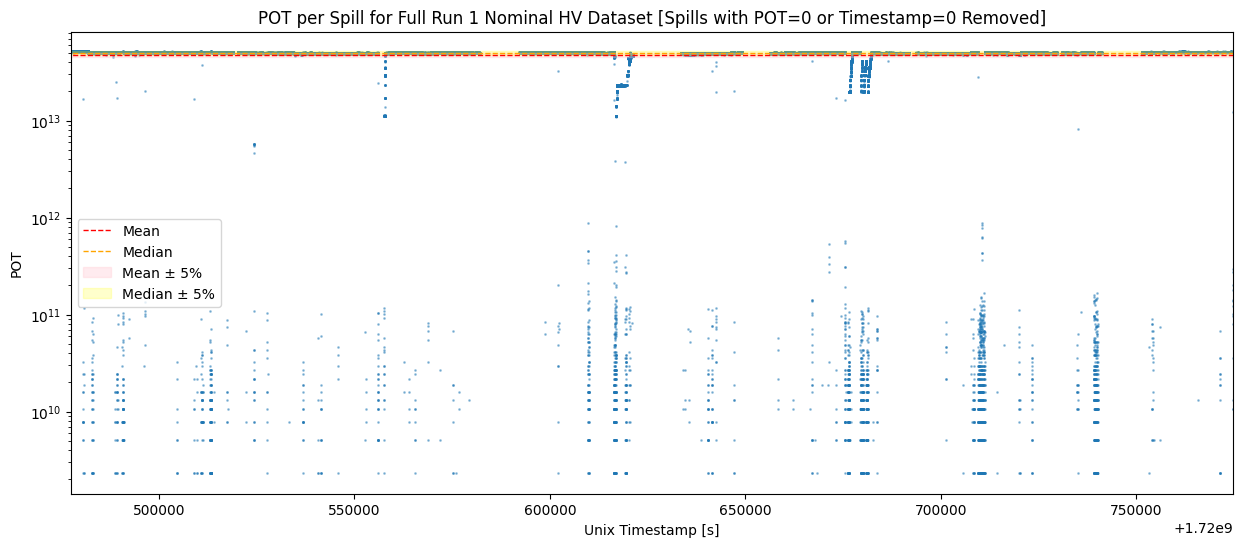

In [55]:
fig, ax = plt.subplots(figsize=(15, 6))

plt.scatter(start_time, pot, s=1, alpha=0.4)
plt.yscale('log')
plt.ylim(np.min(pot[non_zero_pot_mask]), np.max(pot[non_zero_pot_mask])+3e13)
plt.hlines(np.mean(pot), xmin=0, xmax=1.73*1e9, color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.hlines(np.median(pot), xmin=0, xmax=1.73*1e9, color='orange', linestyle='dashed', linewidth=1, label='Median')
mean_five_percent = np.mean(pot)*0.05
mean_upper = np.mean(pot) + mean_five_percent
mean_lower = np.mean(pot) - mean_five_percent
plt.fill_between([0, 1.73*1e9], mean_lower, mean_upper, color='pink', alpha=0.3, label='Mean ± 5%')
median_five_percent = np.median(pot)*0.05
median_upper = np.median(pot) + median_five_percent
median_lower = np.median(pot) - median_five_percent 
plt.fill_between([0, 1.73*1e9], median_lower, median_upper, color='yellow', alpha=0.2, label='Median ± 5%')
plt.legend()
plt.xlim(xmin=np.min(start_time), xmax=np.max(start_time))
plt.ylabel("POT")
plt.xlabel("Unix Timestamp [s]")
plt.title("POT per Spill for Full Run 1 Nominal HV Dataset [Spills with POT=0 or Timestamp=0 Removed]")